# BAAC - Classification 
# Modélisation Regression logistique, arbre de décision et gradient boosting

## Import et chargement

In [52]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, confusion_matrix, f1_score

from sklearn.model_selection import GridSearchCV
import optuna

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/processed/baac_final.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 479684 entries, 0 to 479683
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   grav      479684 non-null  int64  
 1   catu      479684 non-null  int64  
 2   sexe      479684 non-null  float64
 3   lum       479684 non-null  float64
 4   agg       479684 non-null  int64  
 5   atm       479684 non-null  float64
 6   surf      479684 non-null  float64
 7   catv_grp  479684 non-null  str    
 8   issecu    479684 non-null  bool   
 9   age_grp   479684 non-null  str    
 10  vma_grp   479684 non-null  str    
dtypes: bool(1), float64(4), int64(3), str(3)
memory usage: 37.1 MB


## Train-Test Split

In [4]:
X = df.drop(columns='grav')
y = df['grav']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=222
)

## Encodages

In [6]:
cat_features = ['catu','sexe','lum','agg','atm','surf','catv_grp','age_grp','vma_grp']

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_features
        )
    ],
    remainder='passthrough'
)

## Baseline

In [8]:
baseline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])

In [9]:
baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['catu','sexe','lum',...,'issecu','age_grp','vma_grp']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not 

In [10]:
y_pred_baseline = baseline.predict(X_test)

In [11]:
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90     78712
           1       0.00      0.00      0.00     17225

    accuracy                           0.82     95937
   macro avg       0.41      0.50      0.45     95937
weighted avg       0.67      0.82      0.74     95937



## Regression Logistique

In [12]:
log_model_b = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LogisticRegression(class_weight='balanced',max_iter=1000))
    ])

In [13]:
log_model_b.fit(X_train, y_train)
y_pred_log_b = log_model_b.predict(X_test)

In [14]:
print(classification_report(y_test,y_pred_log_b))

              precision    recall  f1-score   support

           0       0.92      0.67      0.78     78712
           1       0.33      0.73      0.45     17225

    accuracy                           0.68     95937
   macro avg       0.62      0.70      0.62     95937
weighted avg       0.81      0.68      0.72     95937



In [15]:
cm = confusion_matrix(y_test,y_pred_log_b)
cm

array([[53119, 25593],
       [ 4704, 12521]])

<Axes: >

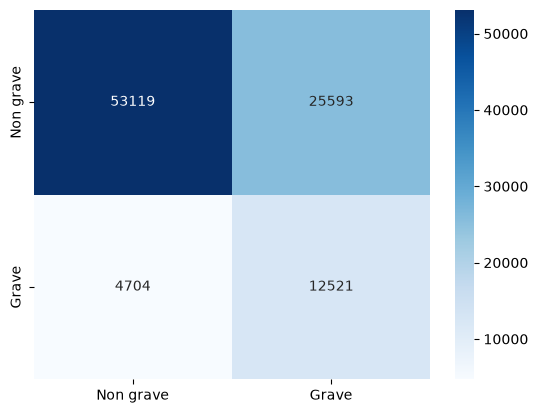

In [16]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non grave', 'Grave'],
    yticklabels=['Non grave', 'Grave']
)

### Interprétation

La régression logistique avec class_weight='balanced' obtient une accuracy de 68 %. Le recall de la classe 1 atteint 73 % et son F1-score 0,45, ce qui montre une meilleure détection des accidents graves. En contrepartie, le modèle produit de nombreux faux positifs et le recall de la classe 0 diminue à 67 %. La pondération des classes favorise donc clairement la détection des accidents graves au détriment de la classe majoritaire.

## Decision Tree

In [17]:
tree_model = Pipeline([
    ('preprocessor',preprocessor),
    ('model',DecisionTreeClassifier(class_weight='balanced',random_state=222))
])

In [18]:
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [19]:
print(classification_report(y_test,y_pred_tree))

              precision    recall  f1-score   support

           0       0.92      0.68      0.78     78712
           1       0.33      0.72      0.45     17225

    accuracy                           0.69     95937
   macro avg       0.62      0.70      0.62     95937
weighted avg       0.81      0.69      0.72     95937



<Axes: >

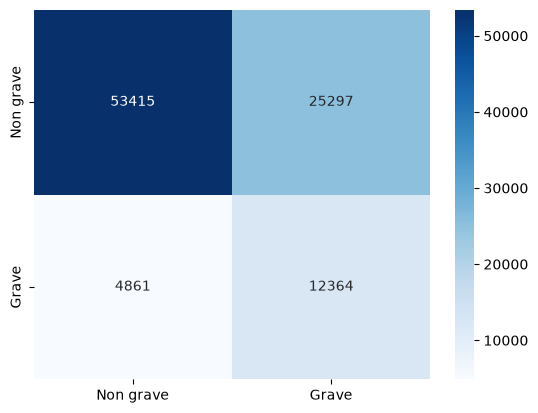

In [20]:
cm = confusion_matrix(y_test,y_pred_tree)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non grave', 'Grave'],
    yticklabels=['Non grave', 'Grave']
)

### Interprétation 

Le Decision Tree avec class_weight='balanced' obtient une accuracy de 69 %. Pour la classe 1, le recall atteint 72 % et le F1-score 0,45. Ses performances sont donc très proches de celles de la régression logistique équilibrée. Le modèle détecte une part importante des accidents graves, mais au prix d'une baisse des performances sur la classe 0.

## Random Forest

In [21]:
forest_model = Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestClassifier(class_weight='balanced',n_estimators=100,random_state=777,n_jobs=1))
     ])

In [22]:
forest_model.fit(X_train, y_train)
y_pred_forest = forest_model.predict(X_test)

In [23]:
print(classification_report(y_test,y_pred_forest))

              precision    recall  f1-score   support

           0       0.92      0.68      0.78     78712
           1       0.33      0.72      0.45     17225

    accuracy                           0.69     95937
   macro avg       0.62      0.70      0.62     95937
weighted avg       0.81      0.69      0.72     95937



<Axes: >

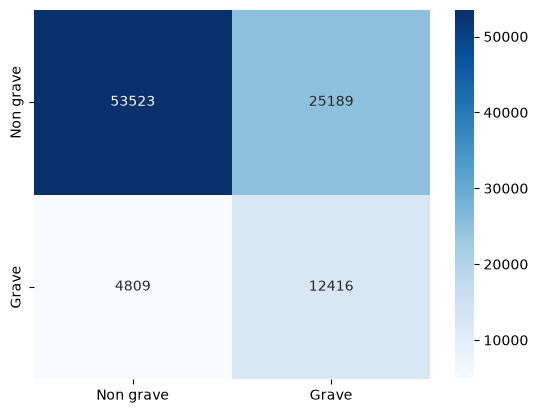

In [24]:
cm = confusion_matrix(y_test,y_pred_forest)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non grave', 'Grave'],
    yticklabels=['Non grave', 'Grave']
)

### Interprétation 
Le Random Forest avec class_weight='balanced' obtient les mêmes performances arrondies que le Decision Tree : 69 % d'accuracy, 72 % de recall et 0,45 de F1-score pour la classe 1. Dans cette configuration, l'utilisation de plusieurs arbres n'apporte donc pas d'amélioration notable par rapport au Decision Tree.

## Gradient Boosting

In [25]:
gradb_model = Pipeline([
    ('preprocessor',preprocessor),
    ('model',GradientBoostingClassifier(n_estimators=100, random_state=111))
    ])

In [26]:
gradb_model.fit(X_train,y_train)
y_pred_gradb = gradb_model.predict(X_test)

In [27]:
print(classification_report(y_test,y_pred_gradb))

              precision    recall  f1-score   support

           0       0.85      0.97      0.90     78712
           1       0.58      0.19      0.29     17225

    accuracy                           0.83     95937
   macro avg       0.71      0.58      0.59     95937
weighted avg       0.80      0.83      0.79     95937



<Axes: >

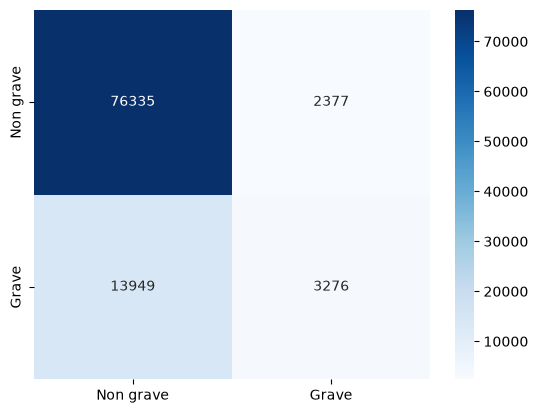

In [28]:
cm = confusion_matrix(y_test,y_pred_gradb)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non grave', 'Grave'],
    yticklabels=['Non grave', 'Grave']
)

### Interprétation 

Le Gradient Boosting obtient une accuracy de 83 %, supérieure à celle des trois modèles équilibrés précédents. Cependant, son recall pour la classe 1 n'est que de 19 % et son F1-score de 0,29. Il détecte donc beaucoup moins d'accidents graves. Cette accuracy plus élevée s'explique notamment par une meilleure performance sur la classe majoritaire, mais elle ne traduit pas une meilleure capacité à identifier les accidents graves.

## Comparaison générale

### Comparaison des modèles

| Modèle              | Accuracy | Precision classe 1 | Recall classe 1 | F1-score classe 1 |
| ------------------- | -------: | -----------------: | --------------: | ----------------: |
| Baseline            |     0,82 |               0,00 |            0,00 |              0,00 |
| Logistic Regression |     0,68 |               0,33 |        **0,73** |          **0,45** |
| Decision Tree       |     0,69 |               0,33 |            0,72 |              0,45 |
| Random Forest       |     0,69 |               0,33 |            0,72 |              0,45 |
| Gradient Boosting   | **0,83** |           **0,58** |            0,19 |              0,29 |


La baseline obtient une accuracy de 82 %, mais ne détecte aucun accident grave. Les modèles Logistic Regression, Decision Tree et Random Forest présentent des performances très proches : leur accuracy est comprise entre 68 % et 69 %, avec un recall de 72 à 73 % et un F1-score de 0,45 pour la classe 1. Ils permettent donc de mieux identifier les accidents graves, mais au prix d'une baisse des performances sur la classe 0.

Le Gradient Boosting se distingue par une accuracy plus élevée de 83 %, mais son recall pour la classe 1 n'est que de 19 % et son F1-score de 0,29. Il détecte donc nettement moins bien les accidents graves. Cette différence peut notamment s'expliquer par le fait que ce modèle n'utilise pas de pondération des classes dans cette configuration.

Globalement, les trois premiers modèles présentent des performances similaires sur la classe grave, tandis que le Gradient Boosting privilégie davantage la prédiction de la classe majoritaire.

## Choix du modèle final

Au regard des résultats obtenus, la **régression logistique est retenue comme modèle final de référence**. Elle obtient le meilleur recall pour la classe 1 avec 73 %, tout en conservant un F1-score de 0,45, équivalent à ceux du Decision Tree et du Random Forest.

Ce choix est cohérent avec l'objectif du projet, qui consiste à identifier au mieux les accidents graves. Le modèle pourra toutefois être optimisé dans la suite du projet afin de déterminer si ses performances peuvent encore être améliorées.

## Optimisation avec GridSearchCV

Pour la régression logistique, le paramètre le plus important à tester simplement est C :

C faible → régularisation plus forte
C élevé → régularisation plus faible

In [29]:
param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10]
}

In [30]:
log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced',max_iter=1000))
])

In [31]:
grid_search = GridSearchCV(
    log_model,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [32]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with

In [33]:
grid_search.best_params_

{'model__C': 10}

In [34]:
grid_search.best_score_

np.float64(0.45260790748322516)

In [35]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.92      0.68      0.78     78712
           1       0.33      0.73      0.45     17225

    accuracy                           0.68     95937
   macro avg       0.62      0.70      0.62     95937
weighted avg       0.81      0.68      0.72     95937



### Résultats de l'optimisation

| Métrique classe 1 | Avant optimisation | Après optimisation |
| ----------------- | -----------------: | -----------------: |
| Precision         |               0,33 |               0,33 |
| Recall            |               0,73 |               0,73 |
| F1-score          |               0,45 |               0,45 |

L'optimisation de la régression logistique par GridSearchCV sélectionne une valeur de `C = 10`, avec un F1-score moyen de 0,453 en validation croisée. Cependant, l'évaluation sur le jeu de test donne des performances quasiment identiques au modèle initial : un recall de 73 % et un F1-score de 0,45 pour la classe 1, avec une accuracy de 68 %.

L'optimisation de l'hyperparamètre `C` n'apporte donc pas d'amélioration significative des performances du modèle.


In [36]:
y_proba = best_model.predict_proba(X_test)[:, 1]

### tester le seuil de décision
Le modèle a déjà un recall de 73 %, donc il peut être intéressant de voir si on peut augmenter le recall de la classe 1 en abaissant le seuil de 0.5.

In [37]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_threshold)
    print(f"Seuil {threshold} → F1 : {f1:.3f}")

Seuil 0.3 → F1 : 0.397
Seuil 0.4 → F1 : 0.429
Seuil 0.5 → F1 : 0.453
Seuil 0.6 → F1 : 0.449
Seuil 0.7 → F1 : 0.394


Le seuil de 0,5 reste le meilleur parmi ceux que tu as testés. Donc modifier le seuil ne permet pas d'améliorer ton F1-score ici.

## Optimisation avec Optuna

In [38]:
def objective(trial):

    C = trial.suggest_float(
        'C',
        1e-4,
        100,
        log=True
    )

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            C=C,
            penalty='l2',
            class_weight='balanced',
            max_iter=1000
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    return f1_score(y_test, y_pred)

In [39]:
study = optuna.create_study(direction='maximize')

study.optimize(
    objective,
    n_trials=20
)

[I 2026-09-29 19:58:36,028] A new study created in memory with name: no-name-7cb4c326-3676-4e0d-9d60-4975ebec875e
[I 2026-09-29 19:58:39,802] Trial 0 finished with value: 0.4520530638029059 and parameters: {'C': 5.9399360872422315}. Best is trial 0 with value: 0.4520530638029059.
[I 2026-09-29 19:58:42,771] Trial 1 finished with value: 0.45249588689410786 and parameters: {'C': 68.00523168376122}. Best is trial 1 with value: 0.45249588689410786.
[I 2026-09-29 19:58:45,851] Trial 2 finished with value: 0.45235946131349963 and parameters: {'C': 0.051588286261881715}. Best is trial 1 with value: 0.45249588689410786.
[I 2026-09-29 19:58:49,400] Trial 3 finished with value: 0.4519395347999207 and parameters: {'C': 0.002411776589626248}. Best is trial 1 with value: 0.45249588689410786.
[I 2026-09-29 19:58:52,580] Trial 4 finished with value: 0.4523234435271639 and parameters: {'C': 0.041143244708821365}. Best is trial 1 with value: 0.45249588689410786.
[I 2026-09-29 19:58:56,220] Trial 5 fini

In [40]:
study.best_params

{'C': 90.70932693191402}

In [41]:
study.best_value

0.4525742807023889

### Résultat de l'optimisation

L'optimisation avec Optuna conduit à une valeur de `C ≈ 9,37`, pour un F1-score moyen de 0,453. Ce résultat est très proche de celui obtenu avec GridSearchCV (`C = 10`, F1-score de 0,453).

L'optimisation de l'hyperparamètre `C` n'apporte donc pas d'amélioration significative des performances de la régression logistique. Les performances semblent ainsi peu sensibles à ce paramètre dans l'intervalle testé.

## Optimisation de Random Forest
La régression logistique optimisée n’a pas permis d’améliorer significativement le F1-score de la classe 1. Nous passons donc au Random Forest, capable de modéliser des relations non linéaires et des interactions entre les variables.

In [42]:
def objective_rf(trial):

    n_estimators = trial.suggest_int('n_estimators', 100, 300)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical(
        'max_features',
        ['sqrt', 'log2']
    )

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    return f1_score(y_test, y_pred)

In [43]:
study_rf = optuna.create_study(direction='maximize')

study_rf.optimize(
    objective_rf,
    n_trials=10
)

[I 2026-09-29 19:59:39,222] A new study created in memory with name: no-name-7e8b7d09-3e31-4c62-9b68-cbbc87f16723
[I 2026-09-29 20:00:16,369] Trial 0 finished with value: 0.4430676435396896 and parameters: {'n_estimators': 199, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.4430676435396896.
[I 2026-09-29 20:00:45,614] Trial 1 finished with value: 0.4355743882518478 and parameters: {'n_estimators': 195, 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.4430676435396896.
[I 2026-09-29 20:05:16,306] Trial 2 finished with value: 0.4627578132036387 and parameters: {'n_estimators': 245, 'max_depth': 26, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.4627578132036387.
[I 2026-09-29 20:08:34,040] Trial 3 finished with value: 0.46126399830430637 and parameters: {'n_estimators': 261, 'max_depth': 25, '

In [46]:
study_rf.best_params

{'n_estimators': 245,
 'max_depth': 26,
 'min_samples_split': 7,
 'min_samples_leaf': 6,
 'max_features': 'sqrt'}

In [47]:
study_rf.best_value

0.4627578132036387

In [ ]:
## Entrainement du modèle avec

In [48]:
best_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=245,
        max_depth=26,
        min_samples_split=7,
        min_samples_leaf=6,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [49]:
best_rf.fit(X_train, y_train)

y_pred_rf = best_rf.predict(X_test)

In [50]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.68      0.78     78712
           1       0.34      0.75      0.46     17225

    accuracy                           0.69     95937
   macro avg       0.63      0.71      0.62     95937
weighted avg       0.82      0.69      0.72     95937



## CatBoosting

In [54]:
for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [55]:
cat_indices = [X_train.columns.get_loc(col) for col in cat_features]

In [56]:
catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='F1',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=False
)

In [57]:
catboost_model.fit(X_train,y_train,cat_features=cat_indices)
y_pred_cat = catboost_model.predict(X_test)

In [58]:
print(classification_report(y_test,y_pred_cat))

              precision    recall  f1-score   support

           0       0.93      0.67      0.78     78712
           1       0.33      0.76      0.46     17225

    accuracy                           0.69     95937
   macro avg       0.63      0.71      0.62     95937
weighted avg       0.82      0.69      0.72     95937



In [59]:
cm = confusion_matrix(y_test,y_pred_cat)
cm

array([[52840, 25872],
       [ 4218, 13007]])

<Axes: >

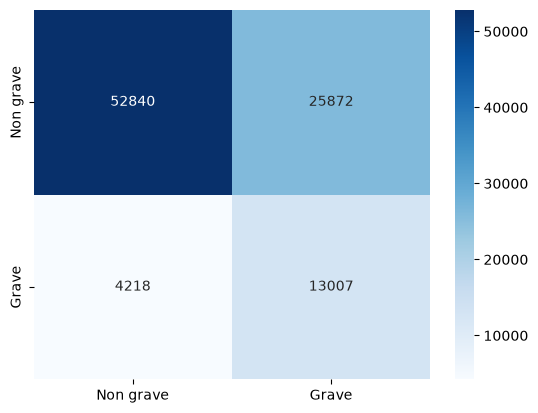

In [60]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non grave', 'Grave'],
    yticklabels=['Non grave', 'Grave']
)  

### Interprétation des résultats

Le modèle CatBoost obtient une accuracy de 69 %. Pour la classe 1, correspondant aux accidents graves, le modèle atteint une precision de 33 %, un recall de 76 % et un F1-score de 0,46.

Le recall de 76 % signifie que le modèle identifie correctement environ trois quarts des accidents graves. En contrepartie, sa precision de 33 % montre qu'une partie importante des prédictions positives correspond à des accidents finalement non graves.

La matrice de confusion montre 13 007 vrais positifs contre 4 218 faux négatifs. Le modèle détecte donc une majorité des accidents graves, mais en identifie également certains comme non graves.

Les performances de CatBoost restent proches de celles du Random Forest optimisé. L'amélioration porte principalement sur le recall de la classe 1, qui atteint 76 %, tandis que le F1-score reste à 0,46.

### Choix du modèle final

À l’issue des différentes expérimentations, **CatBoost est retenu comme modèle final**. La régression logistique obtenait un recall de **73 %** pour la classe 1, contre **75 % pour le Random Forest optimisé** et **76 % pour CatBoost**. CatBoost permet donc de détecter légèrement plus d’accidents graves, avec une accuracy de **69 %** et un F1-score de **0,46**.

Cette amélioration reste toutefois limitée par rapport au Random Forest optimisé, qui obtient également un F1-score de 0,46. CatBoost présente en revanche une precision de **33 %**, ce qui correspond à un nombre important de faux positifs. Le choix de CatBoost repose donc principalement sur son **recall légèrement supérieur**, en cohérence avec l’objectif prioritaire du projet : détecter les accidents graves.

## Conclusion

Cette phase de modélisation avait pour objectif de prédire la gravité des accidents et plus particulièrement d'identifier les cas graves. La baseline atteignait 82 % d'accuracy, mais ne détectait aucun accident grave. Les modèles testés ont permis d'améliorer fortement la détection de la classe 1, avec un recall compris entre 72 % et 76 %.

Après optimisation, **CatBoost est retenu comme modèle final**, avec une accuracy de 69 %, un recall de **76 %** et un F1-score de **0,46** pour la classe grave. Ce résultat permet d'identifier une majorité des accidents graves, mais s'accompagne d'un nombre important de faux positifs, avec une precision de 33 %.

Les résultats montrent ainsi que la détection des accidents graves reste difficile à partir des variables retenues. Le modèle final constitue un compromis entre la capacité à détecter les cas graves et le nombre de fausses alertes.
